In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('train.csv')
df.set_index('id',inplace = True)

In [4]:
cat_cols = ["job", "marital", "education", "default", "housing",
            "loan", "contact", "month", "poutcome"]

# Tworzymy OHE
df_ohe = pd.get_dummies(df, columns=cat_cols, drop_first=False)  # drop_first=True jeśli chcesz uniknąć dummy trap

df_ohe

,age,balance,day,duration,campaign,pdays,previous,y,job_admin.,job_blue-collar,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
id,,,,,,,,,,,,,,,,,,,,,
0,42,7,25,117,3,-1,0,0,False,False,...,False,False,False,False,False,False,False,False,False,True
1,38,514,18,185,1,-1,0,0,False,True,...,True,False,False,False,False,False,False,False,False,True
2,36,602,14,111,2,-1,0,0,False,True,...,False,False,True,False,False,False,False,False,False,True
3,27,34,28,10,2,-1,0,0,False,False,...,False,False,True,False,False,False,False,False,False,True
4,26,889,3,902,1,-1,0,1,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,29,1282,4,1006,2,-1,0,1,False,False,...,False,False,False,False,False,False,False,False,False,True
749996,69,631,19,87,1,-1,0,0,False,False,...,False,False,False,False,False,False,False,False,False,True
749997,50,217,17,113,1,-1,0,0,False,True,...,False,False,False,False,False,False,False,False,False,True


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# X = wszystkie cechy oprócz y
X = df_ohe.drop("y", axis=1)
y = df_ohe["y"]

# Podział na train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

# Model
model = LogisticRegression(max_iter=1000, verbose = 2)  # max_iter większe jeśli dużo cech
model.fit(X_train, y_train)

# Predykcje
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

# Ocena
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


c:\Users\szymo\anaconda3\envs\geo\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   55.7s finished


Accuracy: 0.9111733333333333
ROC AUC: 0.9374240310377274
Confusion Matrix:
 [[127999   3903]
 [  9421   8677]]


In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# Zakładam, że df jest Twój DataFrame i 'y' to 0/1
X = df.drop("y", axis=1)
y = df["y"]

# Rozdzielenie kolumn numerycznych i kategorycznych
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


In [28]:
# Podział na train/test ze stratifikacją
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessing dla kolumn numerycznych i kategorycznych
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Pipeline z Logistic Regression
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=100, solver='liblinear'))  # solver 'liblinear' dobrze działa na małych i średnich datasetach
])

In [29]:
# GridSearchCV dla parametru C (regularyzacja)
param_grid = {
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2']
}
# n jobs = -1 ife we want all proccessor cores
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose = 2)
grid.fit(X_train, y_train)

# Najlepsze parametry i wynik
print("Best params:", grid.best_params_)
print("Best CV ROC AUC:", grid.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'clf__C': 0.01, 'clf__penalty': 'l1'}
Best CV ROC AUC: 0.9419351613594769


In [30]:
# Predykcje na teście
y_pred = grid.predict(X_test)
y_proba = grid.predict_proba(X_test)[:,1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 0.915
Test ROC AUC: 0.9425097658919389
Confusion Matrix:
 [[128225   3677]
 [  9073   9025]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95    131902
           1       0.71      0.50      0.59     18098

    accuracy                           0.92    150000
   macro avg       0.82      0.74      0.77    150000
weighted avg       0.91      0.92      0.91    150000



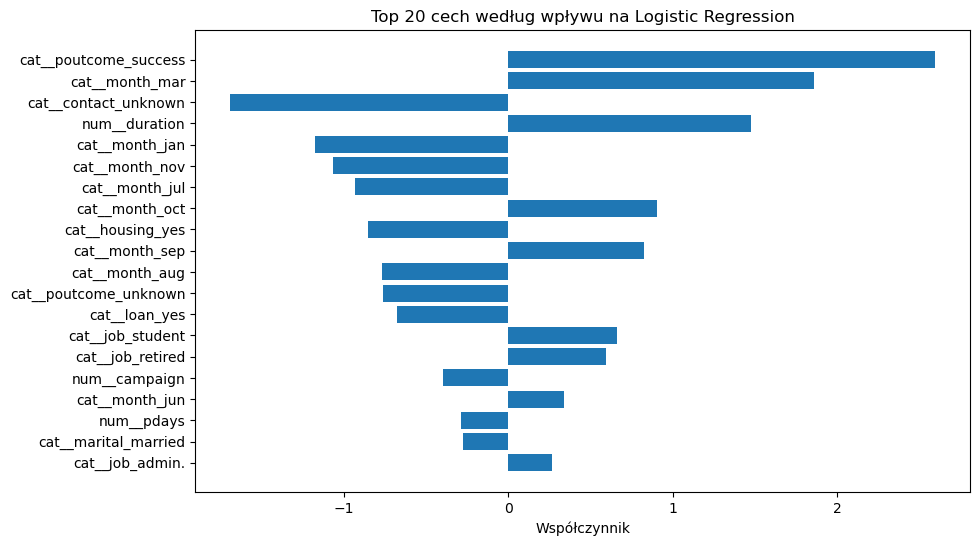

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Pobranie nazw cech po One-Hot Encoding
feature_names = grid.best_estimator_['preprocessor'].get_feature_names_out()

# Współczynniki modelu
coefs = grid.best_estimator_['clf'].coef_[0]

# Posortowane według wartości absolutnej
indices = np.argsort(np.abs(coefs))[::-1]

plt.figure(figsize=(10,6))
plt.barh(range(20), coefs[indices][:20])  # top 20 cech
plt.yticks(range(20), feature_names[indices][:20])
plt.xlabel("Współczynnik")
plt.title("Top 20 cech według wpływu na Logistic Regression")
plt.gca().invert_yaxis()
plt.show()

In [34]:
from sklearn.tree import DecisionTreeClassifier

# X i y
X = df.drop("y", axis=1)
y = df["y"]

# Kolumny numeryczne i kategoryczne
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

In [35]:
# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessing: One-Hot Encoding dla kategorii
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'  # kolumny numeryczne przechodzą bez zmian
)

# Pipeline z Decision Tree
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=42))
])

In [36]:
# GridSearchCV: max_depth i min_samples_split
param_grid = {
    'clf__max_depth': [3, 5, 7, 10, None],
    'clf__min_samples_split': [2, 5, 10, 20]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='roc_auc', n_jobs=1, verbose=2)
grid.fit(X_train, y_train)

# Wyniki
print("Best params:", grid.best_params_)
print("Best CV ROC AUC:", grid.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END .........clf__max_depth=3, clf__min_samples_split=2; total time=   3.3s
[CV] END .........clf__max_depth=3, clf__min_samples_split=2; total time=   3.3s
[CV] END .........clf__max_depth=3, clf__min_samples_split=2; total time=   4.7s
[CV] END .........clf__max_depth=3, clf__min_samples_split=2; total time=   4.3s
[CV] END .........clf__max_depth=3, clf__min_samples_split=2; total time=   4.3s
[CV] END .........clf__max_depth=3, clf__min_samples_split=5; total time=   3.9s
[CV] END .........clf__max_depth=3, clf__min_samples_split=5; total time=   3.4s
[CV] END .........clf__max_depth=3, clf__min_samples_split=5; total time=   3.6s
[CV] END .........clf__max_depth=3, clf__min_samples_split=5; total time=   3.3s
[CV] END .........clf__max_depth=3, clf__min_samples_split=5; total time=   2.9s
[CV] END ........clf__max_depth=3, clf__min_samples_split=10; total time=   3.1s
[CV] END ........clf__max_depth=3, clf__min_sam

In [37]:
y_pred = grid.predict(X_test)
y_proba = grid.predict_proba(X_test)[:,1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 0.9229333333333334
Test ROC AUC: 0.9473909109784754
Confusion Matrix:
 [[127934   3968]
 [  7592  10506]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96    131902
           1       0.73      0.58      0.65     18098

    accuracy                           0.92    150000
   macro avg       0.83      0.78      0.80    150000
weighted avg       0.92      0.92      0.92    150000



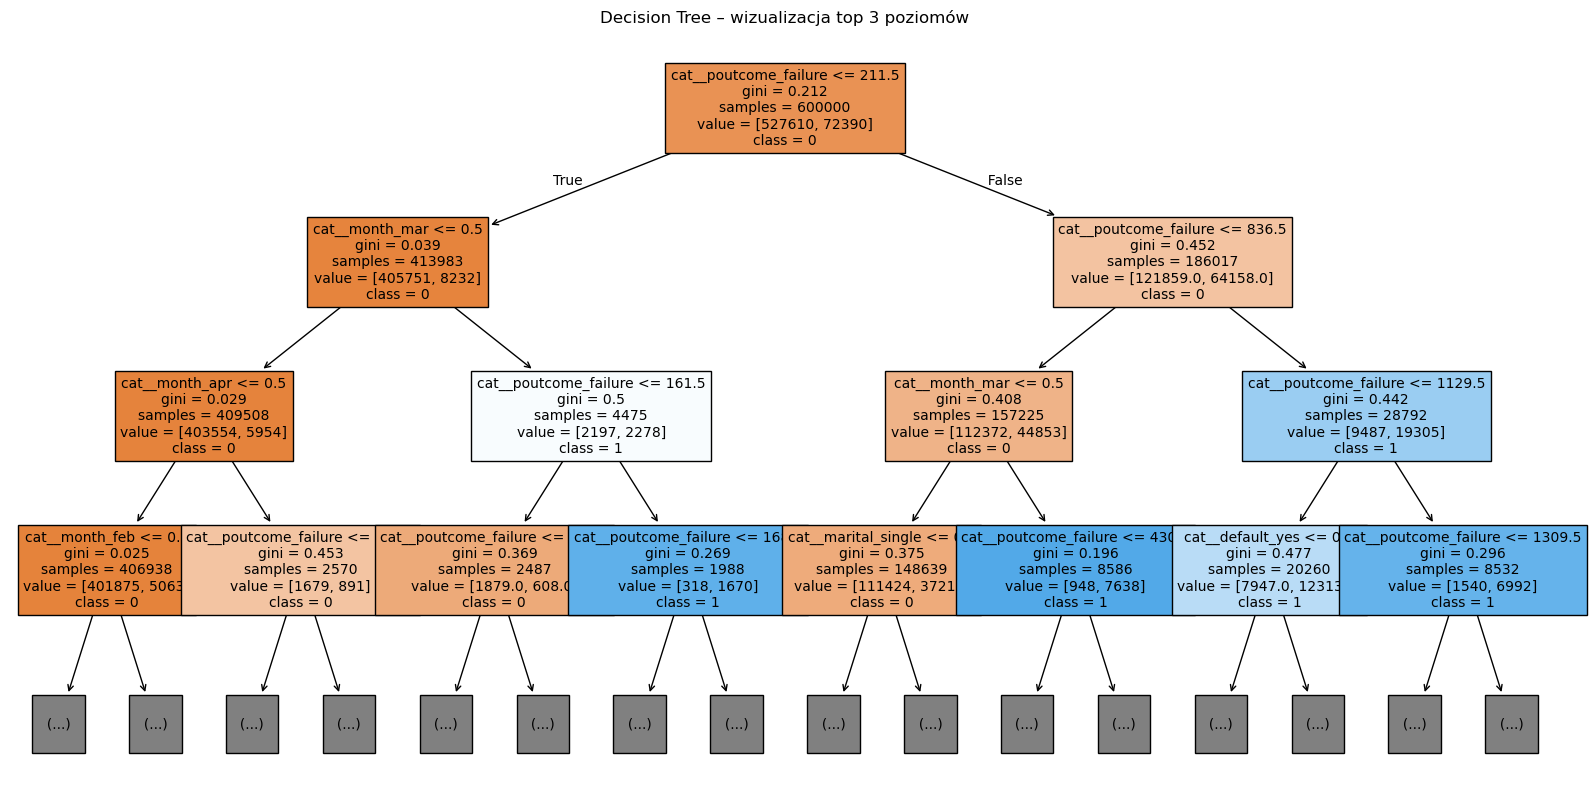

In [38]:
from sklearn.tree import plot_tree

# Pobranie najlepszego drzewa
tree_model = grid.best_estimator_['clf']

plt.figure(figsize=(20,10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=['0','1'],
    filled=True,
    max_depth=3,  # ograniczenie do 3 poziomów dla czytelności
    fontsize=10
)
plt.title("Decision Tree – wizualizacja top 3 poziomów")
plt.show()

In [39]:
from sklearn.ensemble import RandomForestClassifier

# X i y
X = df.drop("y", axis=1)
y = df["y"]

# Kolumny numeryczne i kategoryczne
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

In [40]:
# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessing: One-Hot Encoding dla kategorii
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'  # kolumny numeryczne przechodzą bez zmian
)

# Pipeline z Random Forest
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

In [42]:
# GridSearchCV: n_estimators i max_depth
param_grid = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [5, 7, 10],
    'clf__min_samples_split': [2, 5]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='roc_auc', n_jobs=1, verbose=2)
grid.fit(X_train, y_train)

# Wyniki
print("Best params:", grid.best_params_)
print("Best CV ROC AUC:", grid.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END clf__max_depth=5, clf__min_samples_split=2, clf__n_estimators=50; total time=  20.0s
[CV] END clf__max_depth=5, clf__min_samples_split=2, clf__n_estimators=50; total time=  19.0s
[CV] END clf__max_depth=5, clf__min_samples_split=2, clf__n_estimators=50; total time=  21.6s
[CV] END clf__max_depth=5, clf__min_samples_split=2, clf__n_estimators=50; total time=  20.4s
[CV] END clf__max_depth=5, clf__min_samples_split=2, clf__n_estimators=50; total time=  22.4s
[CV] END clf__max_depth=5, clf__min_samples_split=2, clf__n_estimators=100; total time=  44.8s
[CV] END clf__max_depth=5, clf__min_samples_split=2, clf__n_estimators=100; total time=  38.6s
[CV] END clf__max_depth=5, clf__min_samples_split=2, clf__n_estimators=100; total time=  39.3s
[CV] END clf__max_depth=5, clf__min_samples_split=2, clf__n_estimators=100; total time=  42.1s
[CV] END clf__max_depth=5, clf__min_samples_split=2, clf__n_estimators=100; total time=  

In [43]:
y_pred = grid.predict(X_test)
y_proba = grid.predict_proba(X_test)[:,1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 0.9113933333333334
Test ROC AUC: 0.9537937642261687
Confusion Matrix:
 [[130565   1337]
 [ 11954   6144]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.95    131902
           1       0.82      0.34      0.48     18098

    accuracy                           0.91    150000
   macro avg       0.87      0.66      0.72    150000
weighted avg       0.90      0.91      0.89    150000



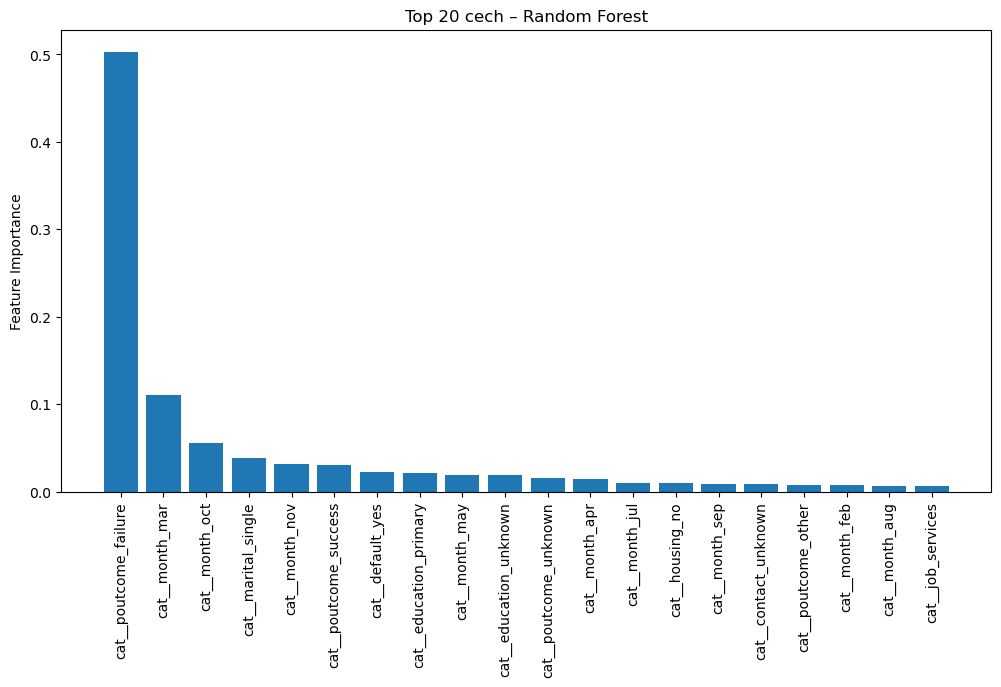

In [44]:
importances = grid.best_estimator_['clf'].feature_importances_

# Posortowane według ważności
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
plt.bar(range(20), importances[indices][:20])
plt.xticks(range(20), feature_names[indices][:20], rotation=90)
plt.ylabel("Feature Importance")
plt.title("Top 20 cech – Random Forest")
plt.show()